# Customer Churn Prediction — E-commerce

This notebook builds an end-to-end churn prediction pipeline based on
e-commerce transaction data. The goal is to identify customers at risk
of not returning, enabling the business team to take targeted retention
actions.

**Dataset:** Dummy e-commerce dataset with 20,400 transaction rows
covering the period 2021–2023, with intentional data quality issues
included to practice the cleaning process.

**Pipeline:** Data Loading → Data Assessing → Data Cleaning →
Feature Engineering → Modeling → Business Insight

# Problem Statement & Executive Summary

## Problem Statement

E-commerce platforms face the challenge of retaining existing customers.
Losing a customer doesn't just mean losing one transaction — it means
losing all potential future revenue from that customer.

This project answers the following business question:

> *"Which customers are at risk of not returning, and how much revenue
> could be lost if they are not addressed?"*

**Approach:**  
Historical transaction data (2021–2023) from 4,909 customers is
transformed into behavioral features at the customer level, then used
to train a binary classification model that predicts each customer's
churn probability. The final output is not just model accuracy — but
concrete, measurable business recommendations.

---

## Executive Summary

| | |
|---|---|
| **Dataset** | 20,400 transactions · 4,909 customers · 2021–2023 |
| **Churn definition** | No transaction in the last 180 days |
| **Churn rate** | 51.3% (2,518 out of 4,909 customers) |
| **Selected model** | Logistic Regression (AUC 0.758, Recall 72%) |
| **Total revenue at risk** | IDR 391.5 million / month |

**Key findings:**
- Customers with high transaction frequency are the least likely to
  churn — the most actionable signal for the business team
- The **Medium-risk** segment (2,405 customers) is the top priority,
  holding the largest revenue at risk: **IDR 171 million/month**
- The **High-risk** segment (1,001 customers) requires immediate
  intervention through reactivation vouchers within 7 days

**Output:**  
A churn probability score per customer that the business team can use
to run prioritized retention campaigns based on risk level and revenue
potential.

# 1. Data Loading

## 1.1 Import Libraries

In [768]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Load CSV

In [769]:
# load csv to notebook
url = '/content/ecommerce_churn_raw.csv'
df = pd.read_csv(url)
df

,order_id,customer_id,order_date,category,price_per_unit,quantity,total_amount,discount_rate,final_amount,payment_method,order_status,review_score,city,delivery_days
0,ORD003483,CUST00040,2023-12-22,Book,134803.06,2,269606.12,0.25,202204.59,debit card,Shipped,5.0,Semarang,NaN
1,ORD009388,CUST04154,2021-05-19,Home and Living,1347554.83,1,1347554.83,0.50,673777.42,credit card,Delivered,NaN,Surabaya,14.0
2,ORD004270,CUST02441,2021-01-18,electronics,60631.69,1,60631.69,NaN,60631.69,Credit Card,Delivered,NaN,Bandung,5.0
3,ORD017130,CUST03536,2021-03-04,Electronics,205553.42,2,411106.84,0.50,205553.42,cod,Shipped,4.0,Surabaya,NaN
4,ORD018789,CUST03077,2021-12-28,BEAUTY,328544.90,4,1314179.60,NaN,985634.70,bank transfer,Delivered,4.0,Medan,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,ORD011285,CUST03952,2023-10-23,automotive,91695.07,4,366780.28,0.05,348441.27,BankTransfer,Delivered,5.0,Makassar,4.0
20396,ORD011965,CUST01208,2023-05-28,electronics,2255636.19,3,6766908.57,0.20,5413526.86,cod,Shipped,4.0,Makassar,NaN
20397,ORD005391,CUST03652,2023-10-26,Beuaty,731473.03,1,731473.03,0.00,731473.03,E-Wallet,Delivered,5.0,Bandung,NaN
20398,ORD000861,CUST03416,2021-11-30,beauty,556195.44,1,556195.44,0.25,417146.58,CreditCard,Cancelled,5.0,Depok,NaN


**Insight:** This dataset consists od 20.400 rows and 14 columns.

# 2. Data Assessing

## 2.1 Initial Inspection

In [770]:
# melihat informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20400 non-null  object 
 1   customer_id     20400 non-null  object 
 2   order_date      20400 non-null  object 
 3   category        20400 non-null  object 
 4   price_per_unit  20400 non-null  float64
 5   quantity        20400 non-null  int64  
 6   total_amount    20400 non-null  float64
 7   discount_rate   19216 non-null  float64
 8   final_amount    20400 non-null  float64
 9   payment_method  19381 non-null  object 
 10  order_status    20400 non-null  object 
 11  review_score    18752 non-null  float64
 12  city            19566 non-null  object 
 13  delivery_days   11665 non-null  float64
dtypes: float64(6), int64(1), object(7)
memory usage: 2.2+ MB


**Insight:**
- The dataset consists of 6 float columns, 1 integer column, and
  7 object columns.
- Missing values are present in `discount_rate`, `payment_method`,
  `review_score`, `city`, and `delivery_days` — these will be handled
  during data cleaning.
- The `order_date` column is typed as string/object. It should be
  datetime since it contains date values — this will also be addressed
  during cleaning.


## 2.2 Missing Values

In [771]:
print("Jumlah data yang hilang")
df.isna().sum()

Jumlah data yang hilang


,0
order_id,0
customer_id,0
order_date,0
category,0
price_per_unit,0
quantity,0
total_amount,0
discount_rate,1184
final_amount,0
payment_method,1019


**Insight:** The table above shows the number of missing values per column:
- discount_rate = 1,184 missing values
- payment_method = 1,019 missing values
- review_score = 1,648 missing values
- city = 834 missing values
- delivery_days = 8,375 missing values

Each of these will be handled systematically during data cleaning.

## 2.3 Descriptive Statistics

In [772]:
print("Statistik Deskriptif")
df.describe()

Statistik Deskriptif


,price_per_unit,quantity,total_amount,discount_rate,final_amount,review_score,delivery_days
count,2.040000e+04,20400.000000,2.040000e+04,19216.000000,2.040000e+04,18752.000000,11665.000000
mean,4.351868e+06,32.259951,8.466598e+05,0.153526,7.191639e+05,3.910090,7.438320
std,6.325630e+07,525.112421,2.440233e+06,0.153778,2.121780e+06,1.138914,4.029468
min,-9.990000e+02,-1.000000,5.000000e+03,0.000000,2.500000e+03,1.000000,1.000000
25%,7.045910e+04,1.000000,1.127368e+05,0.000000,9.204041e+04,3.000000,4.000000
50%,1.617525e+05,1.000000,2.852218e+05,0.100000,2.365253e+05,4.000000,7.000000
75%,3.688191e+05,3.000000,7.391786e+05,0.250000,6.197252e+05,5.000000,11.000000
max,1.000000e+09,9999.000000,1.112216e+08,0.500000,1.112216e+08,5.000000,14.000000


**Insight:** An anomaly was found in `price_per_unit` and `quantity` —
the minimum values should not be negative. This indicates outliers that
need to be addressed during cleaning.

## 2.4 Duplicate Data

In [773]:
print("Jumlah data duplikat")
df.duplicated().sum()

Jumlah data duplikat


np.int64(344)

**Insight:** 344 duplicate rows were found and need to be dropped to
avoid affecting the accuracy of the analysis.

## 2.5 Data assessing summary

The initial inspection identified several data quality issues to address:
- Missing values in 5 columns: review_score (8%), delivery_days (43%),
  payment_method (5%), city (4%), discount_rate (6%)
- 344 fully duplicated rows
- Inconsistent date formats in `order_date` (4 different formats)
- Capitalization inconsistencies and typos in `category` and
  `payment_method`
- Invalid values in `price_per_unit` (negative, zero, 999999999) and
  `quantity` (negative, zero, 9999)

All issues will be addressed systematically in the cleaning phase below.

# 3. Data Cleaning

## 3.1 Handling Missing Values

In [774]:
# menangani missing values pada `discount_rate`
df['discount_rate'].fillna(0, inplace=True)

/tmp/ipykernel_540/2835735603.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['discount_rate'].fillna(0, inplace=True)


**Insight:** Missing values in `discount_rate` are filled with 0,
assuming transactions without a discount simply have no recorded value
in this column.

In [775]:
# menangani missing values pada `city` dan mengisinya dengan 'Unknown'
df['city'] = df['city'].fillna('Unknown')

**Insight:** Missing values in `city` are filled with 'Unknown' to
preserve the transaction data while still allowing city distribution
analysis.

In [776]:
# analisis missing values pada `payment_method`
df[df['payment_method'].isna()]['order_status'].value_counts()

,count
order_status,
Delivered,660
Shipped,125
Processing,122
Cancelled,86
Returned,26


**Insight:** If most missing values came from Cancelled orders, that
would be expected since cancelled orders have no payment method.
However, the highest count of missing values is in Delivered orders —
further analysis is needed before deciding on a treatment.

In [777]:
# lihat presentase missing values pada Delivered
total_delivered = df[df['order_status'] == 'Delivered'].shape[0]
missing_delivered = df[(df['order_status'] == 'Delivered') & (df['payment_method'].isna())].shape[0]

print(f"Total Delivered: {total_delivered}")
print(f"Missing payment_method di Delivered: {missing_delivered}")
print(f"Persentase: {missing_delivered/total_delivered*100:.1f}%")

Total Delivered: 13222
Missing payment_method di Delivered: 660
Persentase: 5.0%


**Insight:** The percentage of missing `payment_method` in Delivered
orders is below 10% — a small enough proportion that data loss would
not significantly impact the analysis.

In [778]:
# mengecek kembali statistik deskriptif pada `final_amount`
df[(df['order_status'] == 'Delivered') &
 (df['payment_method'].isna())][['order_date', 'city', 'final_amount']].describe()

,final_amount
count,6.600000e+02
mean,6.240149e+05
std,1.119358e+06
min,4.414000e+03
25%,8.187797e+04
50%,2.217941e+05
75%,6.165124e+05
max,1.106281e+07


**Insight:** No anomalies were found in the `final_amount` distribution
of the affected rows, suggesting the missing values are likely due to
random recording errors rather than a systematic pattern.

In [779]:
# mengisi missing values pada `payment_method` dengan nilai 'Unknown'
df['payment_method'] = df['payment_method'].fillna('Unknown')

**Insight:** A total of 1,019 rows have missing in `payment_method`.
Analysis shows 660 of these are Delivered orders with a normal
`final_amount` distribution — no systematic pattern was found. Missing
values are treated as random and filled with 'Unknown' to retain valid
transaction data.

In [780]:
# mengisi missing values pada `review_score` dengan nilai median dan biarkan nilai NaN
# membuat kolom flag baru yang menandakan apakah nilai 'review_score' asli adalah NaN (1) atau tidak (0).
df['review_missing_flag'] = df['review_score'].isna().astype(int)
df['review_score'] = df['review_score'].fillna(df['review_score'].median())

**Insight:** Missing values in `review_score` are filled with the
median value.

In [781]:
# analisis missing values pada `delivery_days`
df.groupby('order_status')['delivery_days'].apply(lambda x: x.isna().sum())

,delivery_days
order_status,
Cancelled,1495
Delivered,1557
Processing,2088
Returned,621
Shipped,2974


**Insight:** 1,557 Delivered rows have no `delivery_days` — this is
unusual since a delivered order should always have a recorded delivery
time. Further analysis is required.


In [782]:
# cek presentase missing Delivered
total_delivered = df[df['order_status'] == 'Delivered'].shape[0]
missing_del_days = df[(df['order_status'] == 'Delivered') & (df['delivery_days'].isna())].shape[0]

print(f"Total Delivered: {total_delivered}")
print(f"Missing delivery_days di Delivered: {missing_del_days}")
print(f"Persentase: {missing_del_days/total_delivered*100:.1f}%")

Total Delivered: 13222
Missing delivery_days di Delivered: 1557
Persentase: 11.8%


**Insight:** 11.8% of Delivered orders are missing in `delivery_days`.
Since this is not random (likely a data entry issue), missing values
are imputed using the median delivery days from other Delivered orders
only — not the full dataset.

In [783]:
# mengisi missing values pada `delivery_days` dengan median
# membuat kolom flag baru yang menandakan apakah nilai `delivery_days` asli adalah NaN (1) atau tidak (0)
df['delivery_days_missing_flag'] = df['delivery_days'].isna().astype(int)

# hitung median hanya dari baris Delivered yang tidak missing
median_delivery = df[
    (df['order_status'] == 'Delivered') &
    (df['delivery_days'].notna())
]['delivery_days'].median()

# isi missing hanya untuk baris Delivered
df.loc[
    (df['order_status'] == 'Delivered') & (df['delivery_days'].isna()),
    'delivery_days'
] = median_delivery

**Insight:** A `delivery_days_missing_flag` column is added to mark
imputed rows. Non-Delivered orders are left as NaN since they have no
delivery time by definition.

In [784]:
# cek apakah masih ada missing values dari Delivered
df[df['delivery_days'].isna()]['order_status'].value_counts()

,count
order_status,
Shipped,2974
Processing,2088
Cancelled,1495
Returned,621


**Insight:** No more missing values remain in Delivered rows —
the imputation was applied correctly.

## 3.2 Handling Duplicates

In [785]:
print("jumlah duplikasi sebelum di drop:")
df.duplicated().sum()

# liat contoh baris duplikat sebelum di drop
df[df.duplicated(keep=False)].sort_values('order_id')

jumlah duplikasi sebelum di drop:


,order_id,customer_id,order_date,category,price_per_unit,quantity,total_amount,discount_rate,final_amount,payment_method,order_status,review_score,city,delivery_days,review_missing_flag,delivery_days_missing_flag
17019,ORD000113,CUST04968,2023-10-15,sports,124473.07,1,124473.07,0.50,62236.54,Bank Transfer,Delivered,5.0,Bogor,5.0,0,0
18639,ORD000113,CUST04968,2023-10-15,sports,124473.07,1,124473.07,0.50,62236.54,Bank Transfer,Delivered,5.0,Bogor,5.0,0,0
7782,ORD000154,CUST00740,2023-11-05,F&B,561832.09,1,561832.09,0.50,280916.04,debit card,Shipped,4.0,Jakarta,NaN,0,1
19231,ORD000154,CUST00740,2023-11-05,F&B,561832.09,1,561832.09,0.50,280916.04,debit card,Shipped,4.0,Jakarta,NaN,0,1
8414,ORD000228,CUST01332,2023-07-29,sports,1546345.57,3,4639036.71,0.00,4639036.71,debit card,Delivered,5.0,Medan,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18192,ORD019853,CUST02224,2023-10-24,Fashion,177162.74,2,354325.48,0.00,354325.48,E-Wallet,Shipped,5.0,Makassar,NaN,0,1
4897,ORD019925,CUST03633,2021-03-20,toys,3270043.23,1,3270043.23,0.25,2452532.42,cod,Delivered,4.0,Bogor,3.0,0,0
5377,ORD019925,CUST03633,2021-03-20,toys,3270043.23,1,3270043.23,0.25,2452532.42,cod,Delivered,4.0,Bogor,3.0,0,0
4286,ORD019992,CUST03434,2023-06-05,Book,425699.10,2,851398.20,0.05,808828.29,BankTransfer,Returned,1.0,Palembang,NaN,0,1


In [786]:
# cek apakah ada partial duplicate
# cek duplikat berdasarkan `order_id` saja
print(f"order_id duplikat: {df.duplicated(subset=['order_id']).sum()}")

order_id duplikat: 400


**Insight:** 344 duplicates were identified during initial assessment.
After missing value imputation, the count increased to 400 — some rows
that previously differed on NaN columns became identical after being
filled with the same value.

In [787]:
# simpan jumlah sebelum di drop
rows_before = df.shape[0]

# drop data duplikat
df = df.drop_duplicates().reset_index(drop=True)

# verifikasi
rows_after = df.shape[0]
print(f"Baris sebelum: {rows_before}")
print(f"Baris sesudah: {rows_after}")
print(f"Baris dihapus: {rows_before - rows_after}")

Baris sebelum: 20400
Baris sesudah: 20056
Baris dihapus: 344


## 3.3 Standardising Format & Category Inconsistencies

In [788]:
# mengubah tipe data pada order_date menjadi datetime dan mengubah format tanggal agar sama
def parse_mixed_dates(date_series):
    formats = [
        '%Y-%m-%d',
        '%d/%m/%Y',
        '%d-%m-%Y',
        '%Y/%m/%d',
        '%B %d, %Y',
    ]

    result = pd.Series([pd.NaT] * len(date_series), index=date_series.index)
    remaining = date_series.copy()

    for fmt in formats:
        mask = result.isna() & remaining.notna()
        if mask.sum() == 0:
            break
        parsed = pd.to_datetime(remaining[mask], format=fmt, errors='coerce')
        result[mask] = parsed

    return result

df['order_date'] = parse_mixed_dates(df['order_date'])

# Verifikasi
print(f"NaT tersisa: {df['order_date'].isna().sum()}")
df.info()

NaT tersisa: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20056 entries, 0 to 20055
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   order_id                    20056 non-null  object        
 1   customer_id                 20056 non-null  object        
 2   order_date                  20056 non-null  datetime64[ns]
 3   category                    20056 non-null  object        
 4   price_per_unit              20056 non-null  float64       
 5   quantity                    20056 non-null  int64         
 6   total_amount                20056 non-null  float64       
 7   discount_rate               20056 non-null  float64       
 8   final_amount                20056 non-null  float64       
 9   payment_method              20056 non-null  object        
 10  order_status                20056 non-null  object        
 11  review_score                20056 non-n

**Insight:** The `order_date` column has its format changed to datetime and the date has been standardized to have the same format.

In [789]:
# lihat nilai unik pada kolom 'category' sebelum dilakukan standarisasi
print(df['category'].value_counts())
print(f"\nTotal nilai unik: {df['category'].nunique()}")

category
BOOKS                537
Health               535
TOYS                 530
sports               529
Sports               525
FASHION              525
Toy                  524
BEAUTY               524
F&B                  521
home & living        520
food & beverage      515
SPORTS               515
Toys                 514
Home & Living        514
Healt                512
Auto                 507
Home&Living          505
AUTOMOTIVE           504
Automotive           501
Home and Living      498
fashion              498
Books                496
Food and Beverage    493
Beuaty               492
beauty               491
Sport                491
Fasion               490
Food & Beverage      489
health               488
automotive           488
HEALTH               486
Beauty               483
Fashion              483
toys                 476
books                452
Book                 442
ELECTRONICS          408
Electronis           399
Electronics          390
electronics     

In [790]:
# melakukan standarisasi pada kolom `category` dengan mapping
category_mapping = {
    # Books
    "BOOKS": "Books",
    "books": "Books",
    "book": "Books",
    "Book": "Books",
    # Health
    "HEALTH": "Health",
    "health": "Health",
    "healt": "Health",
    "Healt": "Health",
    # Toys
    "TOYS": "Toys",
    "Toy": "Toys",
    "toys": "Toys",
    # Sports
    "SPORTS": "Sports",
    "sport": "Sports",
    "sports": "Sports",
    "Sport": "Sports",
    # Fashion
    "FASHION": "Fashion",
    "fashion": "Fashion",
    "fasion": "Fashion",
    "Fasion": "Fashion",
    # Beauty
    "BEAUTY": "Beauty",
    "beauty": "Beauty",
    "Beuaty": "Beauty",
    # Home & Living
    "home & living": "Home & Living",
    "Home&Living": "Home & Living",
    "Home and Living": "Home & Living",
    # F&B
    "food and beverage": "F&B",
    "Food and Beverage": "F&B",
    "Food & Beverage": "F&B",
    "food & beverage": "F&B",
    # Automotive
    "automotive": "Automotive",
    "Auto": "Automotive",
    "AUTOMOTIVE": "Automotive",
    # Electronics
    "ELECTRONICS": "Electronics",
    "Electronis": "Electronics",
    "electronics": "Electronics",
    "Electronik": "Electronics"
}

df['category'] = df['category'].replace(category_mapping)

In [791]:
# cek kembali kolom `category` yang sudah di mapping
print(df['category'].value_counts())
print(f"\nTotal nilai unik: {df['category'].nunique()}")

category
Sports           2060
Toys             2044
Home & Living    2037
Health           2021
F&B              2018
Automotive       2000
Fashion          1996
Beauty           1990
Electronics      1963
Books            1927
Name: count, dtype: int64

Total nilai unik: 10


**Insight:** After mapping, the `category` column — previously split
into 41 unique values — is consolidated into 10 clean categories:
Sports, Toys, Home & Living, Health, F&B, Automotive, Fashion, Beauty,
Electronics, Books.

In [792]:
# lihat nilai unik pada kolom payment_method sebelum dilakukan standarisasi
print(df['payment_method'].value_counts())
print(f"\nTotal nilai unik: {df['payment_method'].nunique()}")

payment_method
debit card       1523
CreditCard       1522
E-Wallet         1517
e-wallet         1512
ewallet          1503
COD              1493
Debit Card       1471
Credit Card      1462
Bank Transfer    1428
credit card      1420
BankTransfer     1408
bank transfer    1404
cod              1388
Unknown          1005
Name: count, dtype: int64

Total nilai unik: 14


In [793]:
# melakukan standarisasi kolom `payment_method` dengan mapping
payment_mapping = {
    "debit card" : "Debit Card",
    "CreditCard" : "Credit Card",
    "credit card" : "Credit Card",
    "e-wallet" : "E-Wallet",
    "ewallet" : "E-Wallet",
    "cod" : "COD",
    "BankTransfer" : "Bank Transfer",
    "bank transfer" : "Bank Transfer"
}

df['payment_method'] = df['payment_method'].replace(payment_mapping)

# validasi kolom 'payment_method' yang sudah di mapping
print(df['payment_method'].value_counts())
print(f"\nTotal nilai unik: {df['payment_method'].nunique()}")

payment_method
E-Wallet         4532
Credit Card      4404
Bank Transfer    4240
Debit Card       2994
COD              2881
Unknown          1005
Name: count, dtype: int64

Total nilai unik: 6


**Insight:** Before standardisation, `payment_method` had 14 unique
values. After mapping, it has 6 clean values.

## 3.4 Handling Outliers

In [794]:
# investigasi outlier pada kolom `price_per_unit`
print(df['price_per_unit'].describe())
print(f"\nNilai 0 atau negatif: {(df['price_per_unit'] <= 0).sum()}")
print(f"Nilai ekstrem tinggi (> 50.000.000): {(df['price_per_unit'] > 50_000_000).sum()}")

# lihat nilai-nilai yang jelas tidak masuk akal
df[df['price_per_unit'] <= 0]['price_per_unit'].value_counts()

count    2.005600e+04
mean     4.420195e+06
std      6.379427e+07
min     -9.990000e+02
25%      7.044895e+04
50%      1.617525e+05
75%      3.685038e+05
max      1.000000e+09
Name: price_per_unit, dtype: float64

Nilai 0 atau negatif: 145
Nilai ekstrem tinggi (> 50.000.000): 82


,count
price_per_unit,
0.0,82
-999.0,63


**Insight:** Investigation shows 145 rows in `price_per_unit` have
invalid values: 82 extreme highs and 63 negatives (price cannot be
negative).

In [795]:
# mengatasi outlier pada `price_per_unit`
# drop nilai yang jelas invalid (negatif, nol, nilai sentinel seperti -999)
rows_before = df.shape[0]

invalid_mask = (df['price_per_unit'] <= 0) | (df['price_per_unit'] == 999_999_999)
df = df[~invalid_mask].reset_index(drop=True)

print(f"Baris dihapus karena invalid: {rows_before - df.shape[0]}")

# handle outlier tinggi yang masuk akal tapi ekstrem
# cek dulu batas atas menggunakan IQR
Q1 = df['price_per_unit'].quantile(0.25)
Q3 = df['price_per_unit'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"\nQ1: {Q1:,.0f}")
print(f"Q3: {Q3:,.0f}")
print(f"IQR upper bound: {upper_bound:,.0f}")
print(f"Outlier di atas upper bound: {(df['price_per_unit'] > upper_bound).sum()}")

Baris dihapus karena invalid: 227

Q1: 71,764
Q3: 366,750
IQR upper bound: 809,230
Outlier di atas upper bound: 1799


**Insight:** Outlier handling for `price_per_unit` was done in two stages:
- Invalid values (≤ 0 and 999,999,999) were dropped as they cannot
  represent real transactions — 227 rows removed.
- The IQR method produced an upper bound of 809,230 with 1,799 rows
  above it (~9% of the dataset). IQR was not used because the
  Indonesian e-commerce context naturally has a wide price range.

Prices above 809,230 IDR are valid for electronics and premium products.
Instead, business-context bounds were applied: minimum 1,000 IDR and
maximum 25,000,000 IDR.

In [796]:
# tentukan batas berdasarkan konteks bisnis, bukan IQR
# harga di bawah 1.000 IDR tidak masuk akal untuk produk e-commerce
# harga di atas 25.000.000 IDR sangat jarang dan kemungkinan error input

lower_bound_biz = 1_000
upper_bound_biz = 25_000_000

# cek berapa baris yang terdampak
print(f"Di bawah {lower_bound_biz:,}: {(df['price_per_unit'] < lower_bound_biz).sum()}")
print(f"Di atas {upper_bound_biz:,}: {(df['price_per_unit'] > upper_bound_biz).sum()}")

# cap nilai ekstrem
df['price_per_unit'] = df['price_per_unit'].clip(
    lower=lower_bound_biz,
    upper=upper_bound_biz
)

# verifikasi
print(f"\nMin setelah cap: {df['price_per_unit'].min():,.0f}")
print(f"Max setelah cap: {df['price_per_unit'].max():,.0f}")

Di bawah 1,000: 79
Di atas 25,000,000: 0

Min setelah cap: 1,000
Max setelah cap: 25,000,000


**Insight:**
- Lower bound set at IDR 1,000 — no product should be priced below
  this in e-commerce. Upper bound set at IDR 25,000,000 — values above
  this are rare and likely input errors.
- 79 rows fell below the lower bound; 0 rows exceeded the upper bound
  (extreme values were already dropped in the previous step).
- Extreme values were capped using `clip()` rather than dropped — to
  preserve data volume.
- After cleaning, `price_per_unit` ranges from IDR 1,000 to 25,000,000.

In [797]:
# investigasi outlier pada kolom `quantity`
print(df['quantity'].describe())
print(f"\nNilai 0 atau negatif: {(df['quantity'] <= 0).sum()}")
print(f"Nilai ekstrem tinggi (> 100): {(df['quantity'] > 100).sum()}")

# lihat nilai-nilai yang jelas tidak masuk akal
df[df['quantity'] <= 0]['quantity'].value_counts()

count    19829.000000
mean        32.555399
std        527.827038
min         -1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       9999.000000
Name: quantity, dtype: float64

Nilai 0 atau negatif: 100
Nilai ekstrem tinggi (> 100): 101


,count
quantity,
0,54
-1,46


**Insight:** Investigation shows 100 rows in `quantity` have values of
0 or below (quantity cannot be negative), and 101 rows have extreme
values (retail purchases above 100 units are unlikely).

In [798]:
# menangani outlier pada `quantity`
# drop nilai yang invalid (0 dan negatif)
rows_before = df.shape[0]
df = df[df['quantity'] > 0].reset_index(drop=True)
print(f"Baris dihapus karena quantity invalid: {rows_before - df.shape[0]}")

# cap yang ekstrem tinggi
df['quantity'] = df['quantity'].clip(upper=100)

# verifikasi
print(f"\nMin setelah cleaning: {df['quantity'].min()}")
print(f"Max setelah cleaning: {df['quantity'].max()}")
print(f"Total baris tersisa: {df.shape[0]}")

Baris dihapus karena quantity invalid: 100

Min setelah cleaning: 1
Max setelah cleaning: 100
Total baris tersisa: 19729


**Insight:**
- Lower bound set at 1 — purchases below 1 are invalid. Upper bound
  set at 100 — retail transactions above this are rare and likely
  input errors.
- 100 rows were dropped due to invalid quantity values.
- 19,729 rows remain after outlier cleaning.

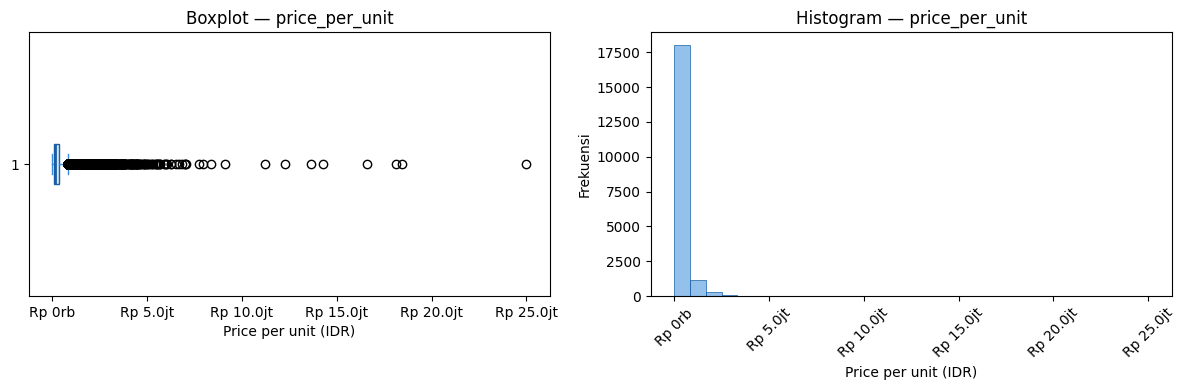

In [799]:
# buat visulisasi boxplot dan histogram untuk `price_per_unit` setelah outlier dibersihkan

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# boxplot
ax1.boxplot(df['price_per_unit'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#378ADD33', color='#185FA5'),
            medianprops=dict(color='#185FA5', linewidth=2),
            whiskerprops=dict(color='#378ADD'),
            capprops=dict(color='#378ADD'))
ax1.set_xlabel('Price per unit (IDR)')
ax1.set_title('Boxplot — price_per_unit')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'))

# histogram
ax2.hist(df['price_per_unit'], bins=30, color='#378ADD88', edgecolor='#185FA5', linewidth=0.5)
ax2.set_xlabel('Price per unit (IDR)')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Histogram — price_per_unit')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The `price_per_unit` distribution is right-skewed. This indicates that the majority of transactions are at low prices (< Rp 5 million), with a long tail to the right up to the upper limit (Rp 25 million). In business terms, this indicates that most customers are from the lower-middle class who purchase low-priced products. Meanwhile, the premium product segment is smaller in volume but still has high revenue potential.

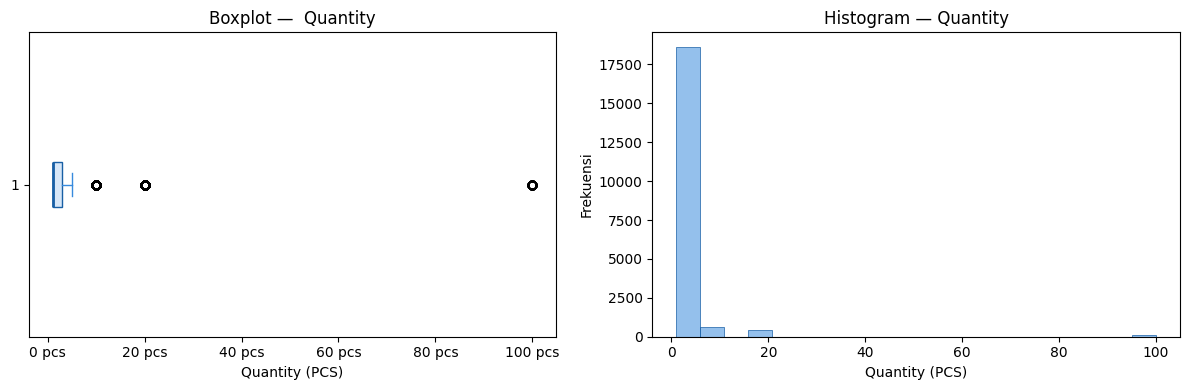

In [800]:
# buat visulisasi boxplot dan histogram untuk `quantity` setelah outlier dibersihkan

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# boxplot
ax1.boxplot(df['quantity'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#378ADD33', color='#185FA5'),
            medianprops=dict(color='#185FA5', linewidth=2),
            whiskerprops=dict(color='#378ADD'),
            capprops=dict(color='#378ADD'))
ax1.set_xlabel('Quantity (PCS)')
ax1.set_title('Boxplot —  Quantity')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)} pcs'))

# histogram
ax2.hist(df['quantity'], bins=20, color='#378ADD88', edgecolor='#185FA5', linewidth=0.5)
ax2.set_xlabel('Quantity (PCS)')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Histogram — Quantity')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)} pcs'))

plt.tight_layout()
plt.savefig('qty_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** From the visualization results above, the quantity distribution is right-skewed. In business terms, this indicates that the majority of customers purchase products in small quantities (<20 pcs) and that bulk purchases (>20 pcs) are rare.

# 4. Final Validation

In [801]:
# cek kembali apakah masih terdapat missing values
df.isna().sum()

,0
order_id,0
customer_id,0
order_date,0
category,0
price_per_unit,0
quantity,0
total_amount,0
discount_rate,0
final_amount,0
payment_method,0


**Insight:** Final validation shows no missing values in the 13 cleaned
columns. The `delivery_days` column still contains 6,946 NaN values —
this is by design, not a data quality issue. NaN is retained for
non-Delivered orders (Shipped, Processing, Cancelled, Returned) since
these orders have no delivery time by definition. This column can still
be used in analysis by filtering for Delivered orders only.

In [802]:
# cek tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19729 entries, 0 to 19728
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   order_id                    19729 non-null  object        
 1   customer_id                 19729 non-null  object        
 2   order_date                  19729 non-null  datetime64[ns]
 3   category                    19729 non-null  object        
 4   price_per_unit              19729 non-null  float64       
 5   quantity                    19729 non-null  int64         
 6   total_amount                19729 non-null  float64       
 7   discount_rate               19729 non-null  float64       
 8   final_amount                19729 non-null  float64       
 9   payment_method              19729 non-null  object        
 10  order_status                19729 non-null  object        
 11  review_score                19729 non-null  float64   

**Insight:** Type validation confirms all columns are in the correct
format: `order_date` is datetime64, numeric columns are float64/int64,
and categorical columns are object.


In [803]:
# simpan dataset yang sudah bersih
df.to_csv('ecommerce_churn_clean.csv', index=False)

**Insight:** The cleaned dataset is saved to a separate file. A total of 19,729 rows
remain from the original 20,400 — reduced by 671 rows due to duplicate
drops (400 rows) and invalid value drops in `price_per_unit` and
`quantity` (271 rows).

# 5. Feature Engineering

## 5.1 Churn Definition

In [804]:
# load dataset yang sudah bersih
df_clean = pd.read_csv('/content/ecommerce_churn_clean.csv')
print("Number of Rows:", df_clean.shape[0])
print("Number of Columns:", df_clean.shape[1])

Number of Rows: 19729
Number of Columns: 16


**Insight:** The dataset consists of 19,729 rows and 16 columns.

In [805]:
# lihat jumlah nilai yang unik berdasarkan `customer_id` dan `order_id`
print("Jumlah customer unik:", df['customer_id'].nunique())
print("Jumlah order unik:", df['order_id'].nunique())

Jumlah customer unik: 4909
Jumlah order unik: 19680


**Insight:** There are 19,680 orders from 4,909 unique customers —
an average of ~4 orders per customer, which is reasonable for an
e-commerce platform.

In [806]:
# cek rentang tanggal transaksi
print(" Paling awal:", df['order_date'].min())
print(" Paling akhir:", df['order_date'].max())

 Paling awal: 2021-01-01 00:00:00
 Paling akhir: 2023-12-31 00:00:00


**Insight:** The dataset covers 3 years of transactions (2021–2023).

In [807]:
# memastikan order_date sudah bertipe datetime
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])

# tentukan snapshot date
snapshot_date = df_clean['order_date'].max()
print("Snapshot date:", snapshot_date)

# hitung tanggal terakhir belanja per customer
last_order = df_clean.groupby('customer_id')['order_date'].max().reset_index()
last_order.columns = ['customer_id', 'last_order_date']

# hitung recency (berapa hari sejak terakhir belanja)
last_order['recency_days'] = (snapshot_date - last_order['last_order_date']).dt.days

# buat churn label untuk batas pembelian terakhir adalah 180 hari
last_order['churn'] = (last_order['recency_days'] > 180).astype(int)

# lihat hasilnya
print("\nDistribusi churn:")
print(last_order['churn'].value_counts())
print(f"\nChurn rate: {last_order['churn'].mean():.1%}")

Snapshot date: 2023-12-31 00:00:00

Distribusi churn:
churn
1    2518
0    2391
Name: count, dtype: int64

Churn rate: 51.3%


**Insight:**
**Churn Definition**

In this project, a customer is defined as **churned** if they have not
made a transaction in the **last 180 days** before the snapshot date
(2023-12-31).

**Rationale for the 180-day threshold:**
- The dataset spans 3 years (2021–2023). A shorter threshold (e.g.
  90 days) produces an unrealistically high churn rate (71.6%)
- A 180-day threshold yields a churn rate of **51.3%** — a near-balanced
  class distribution, ideal for training an ML model
- From a business standpoint, 6 months without a transaction is a
  strong signal that a customer is no longer active

**Formula:**
- `recency_days` = snapshot_date − last_order_date
- `churn = 1` if recency_days > 180
- `churn = 0` if recency_days ≤ 180

## 5.2 Build Customer Table

In [808]:
# hitung avg_delivery_days khusus order Delivered
delivery_avg = df_clean[df_clean['order_status'] == 'Delivered'].groupby('customer_id')['delivery_days'].mean().reset_index()
delivery_avg.columns = ['customer_id', 'avg_delivery_days']

# hitung avg_discount_rate
discount_avg = df_clean.groupby('customer_id')['discount_rate'].mean().reset_index()
discount_avg.columns = ['customer_id', 'avg_discount_rate']

# agregasi semua fitur ke level customer
customer_df = df_clean.groupby('customer_id').agg(
    first_order_date   = ('order_date', 'min'),
    last_order_date    = ('order_date', 'max'),
    frequency          = ('order_id', 'nunique'),
    monetary           = ('final_amount', 'sum'),
    avg_review         = ('review_score', 'mean'),
    cancelled_orders   = ('order_status', lambda x: (x == 'Cancelled').sum()),
    returned_orders    = ('order_status', lambda x: (x == 'Returned').sum()),
    total_orders       = ('order_id', 'nunique'),
    preferred_category = ('category', lambda x: x.mode()[0]),
    preferred_payment  = ('payment_method', lambda x: x.mode()[0]),
).reset_index()

# gabungkan fitur delivery dan discount
customer_df = customer_df.merge(delivery_avg, on='customer_id', how='left')
customer_df = customer_df.merge(discount_avg, on='customer_id', how='left')

# fitur turunan
snapshot_date = pd.Timestamp('2023-12-31')
customer_df['recency_days']      = (snapshot_date - customer_df['last_order_date']).dt.days
customer_df['customer_age_days'] = (snapshot_date - customer_df['first_order_date']).dt.days
customer_df['avg_order_value']   = customer_df['monetary'] / customer_df['frequency']
customer_df['cancel_rate']       = customer_df['cancelled_orders'] / customer_df['total_orders']
customer_df['return_rate']       = customer_df['returned_orders'] / customer_df['total_orders']
customer_df['churn']             = (customer_df['recency_days'] > 180).astype(int)

print("Shape:", customer_df.shape)
print("\nMissing values:")
print(customer_df.isnull().sum())

Shape: (4909, 19)

Missing values:
customer_id             0
first_order_date        0
last_order_date         0
frequency               0
monetary                0
avg_review              0
cancelled_orders        0
returned_orders         0
total_orders            0
preferred_category      0
preferred_payment       0
avg_delivery_days     297
avg_discount_rate       0
recency_days            0
customer_age_days       0
avg_order_value         0
cancel_rate             0
return_rate             0
churn                   0
dtype: int64


**Insight:**
- The customer table consists of 19 columns with missing values in
  `avg_delivery_days`.
- Validation shows 2,518 customers are identified as churned (no
  transaction in the last 180 days) and 2,391 customers are still active.
- The class distribution is nearly balanced — no class imbalance
  handling technique is required for modeling.

In [809]:
# buat flag: apakah customer pernah punya order Delivered
customer_df['has_delivered_order'] = customer_df['avg_delivery_days'].notna().astype(int)

# isi NaN dengan median (hanya untuk keperluan modeling)
median_delivery = customer_df['avg_delivery_days'].median()
customer_df['avg_delivery_days'] = customer_df['avg_delivery_days'].fillna(median_delivery)

# verifikasi
print("Missing values avg_delivery_days:", customer_df['avg_delivery_days'].isnull().sum())
print("Distribusi has_delivered_order:")
print(customer_df['has_delivered_order'].value_counts())

Missing values avg_delivery_days: 0
Distribusi has_delivered_order:
has_delivered_order
1    4612
0     297
Name: count, dtype: int64


**Insight:**
- 297 customers have NaN in `avg_delivery_days` because they have no
  Delivered orders — this is by design, not a data quality issue.
- NaN values are filled with the median for modeling purposes.
- A `has_delivered_order` flag column is added to preserve the
  information that these customers have never received an order.

In [810]:
# validasi tabel customer
print("Lihat kolom yang ada:")
print(customer_df.columns.tolist())
print("\nJumlah kolom:")
print(customer_df.shape[1])

print("\nCek missing values:")
print(customer_df.isna().sum())

Lihat kolom yang ada:
['customer_id', 'first_order_date', 'last_order_date', 'frequency', 'monetary', 'avg_review', 'cancelled_orders', 'returned_orders', 'total_orders', 'preferred_category', 'preferred_payment', 'avg_delivery_days', 'avg_discount_rate', 'recency_days', 'customer_age_days', 'avg_order_value', 'cancel_rate', 'return_rate', 'churn', 'has_delivered_order']

Jumlah kolom:
20

Cek missing values:
customer_id            0
first_order_date       0
last_order_date        0
frequency              0
monetary               0
avg_review             0
cancelled_orders       0
returned_orders        0
total_orders           0
preferred_category     0
preferred_payment      0
avg_delivery_days      0
avg_discount_rate      0
recency_days           0
customer_age_days      0
avg_order_value        0
cancel_rate            0
return_rate            0
churn                  0
has_delivered_order    0
dtype: int64


**Insight:** The final customer table consists of 20 columns with no
remaining missing values.

In [811]:
# simpan tabel customer dalam bentuk csv
customer_df.to_csv('customer_churn_table.csv', index=False)

In [812]:
# load tabel customer yang baru disimpan
customer_df = pd.read_csv('/content/customer_churn_table.csv')
customer_df.head(10)

,customer_id,first_order_date,last_order_date,frequency,monetary,avg_review,cancelled_orders,returned_orders,total_orders,preferred_category,preferred_payment,avg_delivery_days,avg_discount_rate,recency_days,customer_age_days,avg_order_value,cancel_rate,return_rate,churn,has_delivered_order
0,CUST00001,2021-02-06,2022-11-05,5,8460532.35,4.000000,0,0,5,Electronics,Debit Card,8.333333,0.200000,421,1058,1.692106e+06,0.000000,0.0,1,1
1,CUST00002,2021-05-14,2023-07-09,5,5161394.49,3.800000,0,0,5,Home & Living,Bank Transfer,6.500000,0.070000,175,961,1.032279e+06,0.000000,0.0,0,1
2,CUST00003,2021-06-08,2021-06-08,1,307478.12,4.000000,0,0,1,Electronics,E-Wallet,10.000000,0.000000,936,936,3.074781e+05,0.000000,0.0,1,1
3,CUST00004,2021-03-18,2022-05-17,4,1225596.12,4.750000,0,0,4,Automotive,Bank Transfer,8.250000,0.162500,593,1018,3.063990e+05,0.000000,0.0,1,1
4,CUST00005,2021-03-12,2023-10-31,3,226086.02,4.000000,1,0,3,Books,COD,9.000000,0.083333,61,1024,7.536201e+04,0.333333,0.0,0,1
5,CUST00006,2021-07-10,2021-07-10,1,420984.60,5.000000,0,0,1,Health,Credit Card,7.333333,0.000000,904,904,4.209846e+05,0.000000,0.0,1,0
6,CUST00007,2021-08-21,2022-02-13,2,472085.00,4.500000,1,0,2,Automotive,Bank Transfer,4.000000,0.400000,686,862,2.360425e+05,0.500000,0.0,1,1
7,CUST00008,2022-05-23,2023-09-25,4,1120309.79,2.500000,0,0,4,Electronics,Unknown,4.333333,0.087500,97,587,2.800774e+05,0.000000,0.0,0,1
8,CUST00009,2023-10-07,2023-10-07,1,889906.36,3.000000,0,0,1,Home & Living,Debit Card,5.000000,0.300000,85,85,8.899064e+05,0.000000,0.0,0,1
9,CUST00010,2022-03-24,2023-11-20,3,5600156.38,4.333333,0,0,3,F&B,Bank Transfer,7.500000,0.050000,41,647,1.866719e+06,0.000000,0.0,0,1


# 6. Modeling

## 6.1 Select Features (X) & Label (y)

In [813]:
# drop kolom yang tidak relevan
drop_cols = ['customer_id', 'first_order_date', 'last_order_date',
             'cancelled_orders', 'returned_orders', 'preferred_category',
             'preferred_payment', 'recency_days','churn']

# pilih fitur dan label
X = customer_df.drop(columns=drop_cols)
y = customer_df['churn']

print("Fitur yang digunakan:")
print(X.columns.tolist())
print(f"\nJumlah Fitur : {X.shape[1]}")
print(f"\nJumlah data : {X.shape[0]}")

Fitur yang digunakan:
['frequency', 'monetary', 'avg_review', 'total_orders', 'avg_delivery_days', 'avg_discount_rate', 'customer_age_days', 'avg_order_value', 'cancel_rate', 'return_rate', 'has_delivered_order']

Jumlah Fitur : 11

Jumlah data : 4909


**Insight:**
- Non-relevant columns are dropped before splitting the data
- `y` = `churn` — the target column to be predicted
- `X` = all relevant behavioral features
- After dropping non-relevant columns, the dataset has 11 features
  across 4,909 customers

## 6.2 Train-Test Split

In [814]:
# import library sklearn
from sklearn.model_selection import train_test_split

In [815]:
# panggil fungsi untuk membagi data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Jumlah data total: ",len(X))
print("Jumlah data latih: ",len(X_train))
print("Jumlah data test: ",len(X_test))

Jumlah data total:  4909
Jumlah data latih:  3927
Jumlah data test:  982


**Insight:**

The dataset is split with an **80% training / 20% test** ratio.  
`stratify=y` ensures churn class proportions remain balanced in both
subsets. `random_state=42` ensures reproducibility.

- Training set : 3,927 customers
- Test set     : 982 customers

## 6.3 Feature Scaling

In [816]:
# import library sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [817]:
# scaling dengan StandardScaler
scaler = StandardScaler()

# transformasi data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6.4 Model Selection

In [818]:
models = {
    'Logistic Regression'  : LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42),
}

print(f"{'Model':<25} {'Mean AUC':>10} {'Std':>8}")
print("-" * 45)

results = {}
for name, model in models.items():
    # logistic regression pakai data scaled, sisanya tidak perlu
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train

    scores = cross_val_score(model, X_cv, y_train,
                             cv=5, scoring='roc_auc')
    results[name] = scores.mean()
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f}")

best_model = max(results, key=results.get)
print(f"\nModel terbaik: {best_model} (AUC = {results[best_model]:.4f})")

Model                       Mean AUC      Std
---------------------------------------------
Logistic Regression           0.7328   0.0116
Decision Tree                 0.6119   0.0165
Random Forest                 0.7333   0.0156
Gradient Boosting             0.7479   0.0129

Model terbaik: Gradient Boosting (AUC = 0.7479)


**Insight:** Gradient Boosting was selected as the main model for
achieving the highest AUC. Logistic Regression is used as the baseline
model due to its high interpretability.

**Note:** `recency_days` was excluded from the features to prevent
data leakage — it is the direct basis of the churn label.

## 6.5 Model Training

In [819]:
# model 1: Logistic Regression (baseline) — perlu scaling
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# model 2: Gradient Boosting (model utama) — tidak perlu scaling
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

print("Kedua model selesai dilatih!")

Kedua model selesai dilatih!


## 6.6 Model Evaluation

In [820]:
from sklearn.metrics import classification_report

In [821]:
# menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada seluruh algoritma yang sudah dibuat.

# buat prediksi pada data 'X_test' menggunakan kedua model
y_pred_lr = lr.predict(X_test_scaled)
y_pred_gb = gb.predict(X_test)

# tampilkan classification_report untuk Linear Regression
print("Logistic Regression Performance")
print(classification_report(y_test, y_pred_lr))

# tampilkan classification_report untuk Gradient Boosting
print("Gradient Boosting Performance")
print(classification_report(y_test, y_pred_gb))

Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.70      0.68      0.69       478
           1       0.70      0.72      0.71       504

    accuracy                           0.70       982
   macro avg       0.70      0.70      0.70       982
weighted avg       0.70      0.70      0.70       982

Gradient Boosting Performance
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       478
           1       0.72      0.69      0.71       504

    accuracy                           0.70       982
   macro avg       0.70      0.71      0.70       982
weighted avg       0.71      0.70      0.70       982



**Insight:**

**Model Evaluation**  
Both models were evaluated on the test set (982 customers) using:
accuracy, precision, recall, and F1-score.

**Metric definitions:**
- **Precision** → of all customers predicted as churn, what percentage
  actually churned
- **Recall** → of all customers who actually churned, what percentage
  were detected
- **F1-score** → harmonic mean of precision and recall

**Results interpretation:**  
Both models achieve the same accuracy (70%). The difference lies in
the precision-recall trade-off:

- **Logistic Regression** has higher recall (0.72) — better at catching
  customers who will actually churn
- **Gradient Boosting** has higher precision (0.72) — less likely to
  give false churn alerts


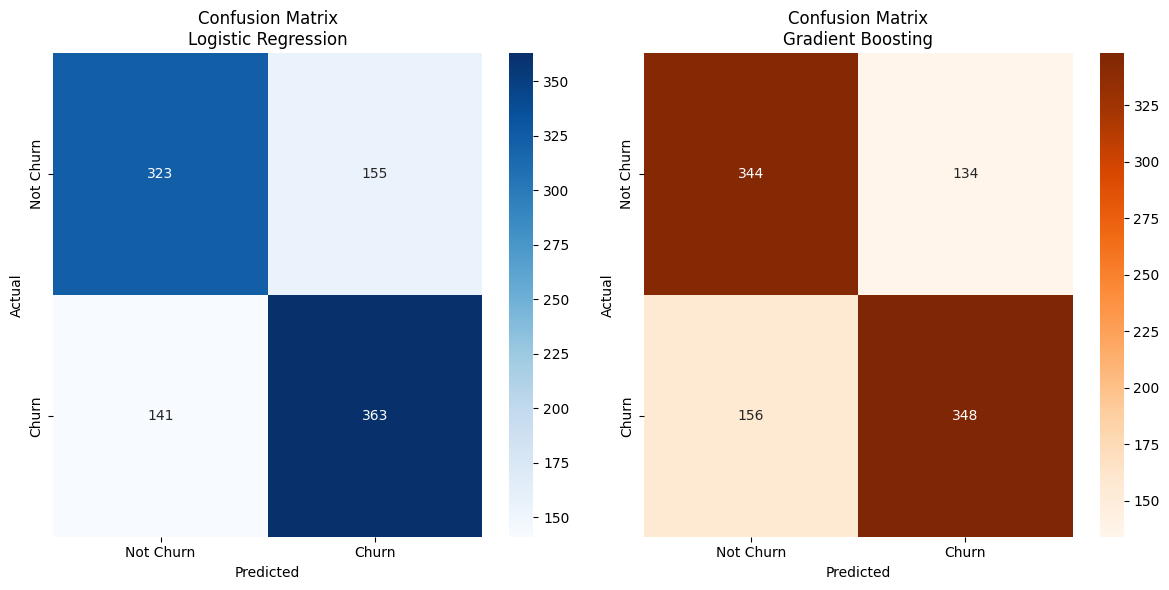

In [822]:
# buat confusion matrix untuk kedua model terbaik
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# confusion matrix untuk Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[0].set_title('Confusion Matrix\nLogistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# confusion matrix untuk Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[1].set_title('Confusion Matrix\nGradient Boosting')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# tampilkan confusion matrix
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

**Insight: Confusion Matrix — Key Findings**

| | Logistic Regression | Gradient Boosting |
|---|---|---|
| Correctly predicted as Not Churn (TN) | 323 | 344 |
| Incorrectly predicted as Churn (FP) | 155 | 134 |
| Incorrectly predicted as Not Churn (FN) | 141 | 156 |
| Correctly predicted as Churn (TP) | 363 | 348 |

The most critical number from a business perspective is the
**False Negative (FN)** — churned customers the model failed to detect.
These are customers who will leave without receiving any retention action.

- Logistic Regression missed **141** churned customers
- Gradient Boosting missed **156** churned customers

Logistic Regression catches **15 more churned customers** than Gradient
Boosting, reinforcing its selection as the more business-relevant model
despite both achieving the same overall accuracy (70%).


In [823]:
# hitung auc untuk kedua model untuk akurasi
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:,1])
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb.predict_proba(X_test)[:,1])
auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)

print(f"AUC untuk Logistic Regression: {auc_lr:.3f}")
print(f"AUC untuk Gradient Boosting: {auc_gb:.3f}")

AUC untuk Logistic Regression: 0.758
AUC untuk Gradient Boosting: 0.760


**Insight:** AUC of Gradient Boosting is slightly higher than Logistic
Regression.


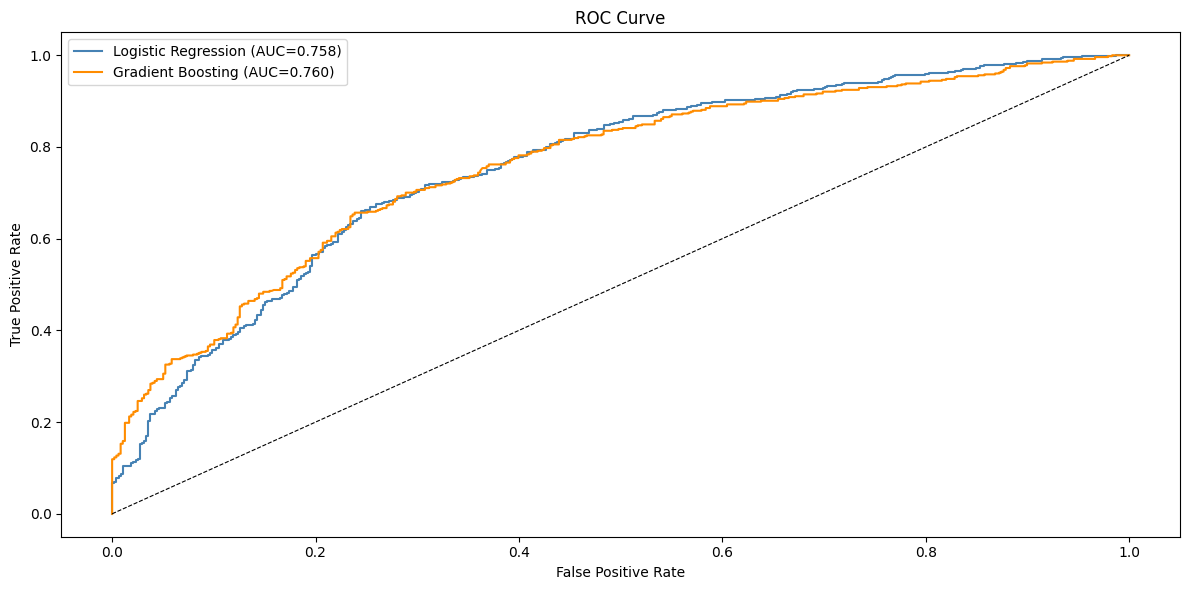

In [824]:
# membuat roc curve
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# roc curve untuk kedua model
axes.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', color='steelblue')
axes.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_gb:.3f})', color='darkorange')
axes.plot([0,1],[0,1], 'k--', linewidth=0.8)
axes.set_xlabel('False Positive Rate')
axes.set_ylabel('True Positive Rate')
axes.set_title('ROC Curve')
axes.legend()

plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

**Insight: Model evaluation summary**

| Metric | Logistic Regression | Gradient Boosting |
|---|---|---|
| Accuracy | 0.70 | 0.70 |
| Precision (churn) | 0.70 | 0.72 |
| Recall (churn) | 0.72 | 0.69 |
| F1-score (churn) | 0.71 | 0.71 |
| AUC-ROC | 0.758 | 0.760 |

In a churn context, **recall is prioritised** over precision. It is
better to incorrectly flag a customer who would not have churned
(small campaign cost) than to miss a customer who is genuinely leaving
(lost revenue).

Given this, **Logistic Regression is selected as the more
business-relevant model** — it detects 363 out of 504 churned customers
(72%), compared to Gradient Boosting's 348 (69%).

## 6.7 Feature Importance
Feature influence analysis using Logistic Regression coefficients.  
Positive values indicate a feature increases churn probability;
negative values indicate it decreases churn probability.

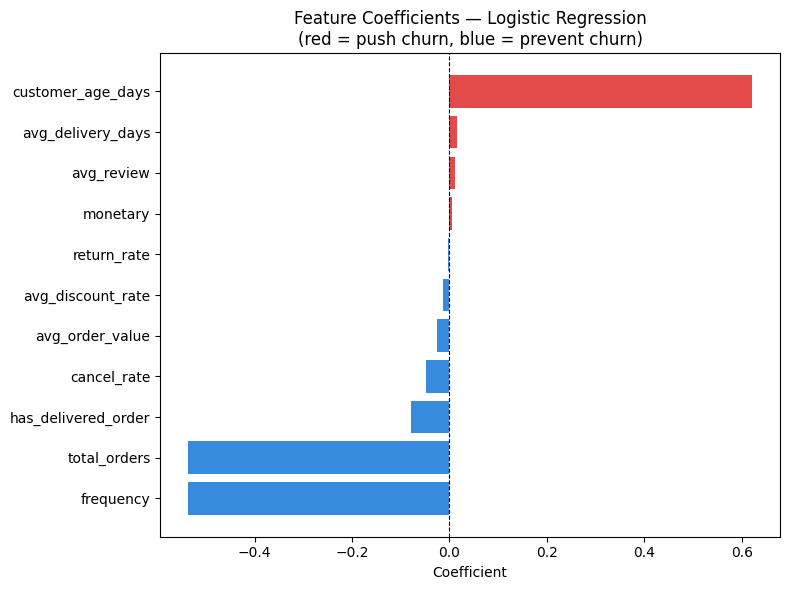

In [825]:
# ambil koefisien dari LR
coef_df = pd.DataFrame({
    'fitur'      : X.columns,
    'koefisien'  : lr.coef_[0]
}).sort_values('koefisien', ascending=True)

# warnai: red = push churn, blue = preevent churn
colors = ['#E24B4A' if c > 0 else '#378ADD' for c in coef_df['koefisien']]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(coef_df['fitur'], coef_df['koefisien'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient')
ax.set_title('Feature Coefficients — Logistic Regression\n(red = push churn, blue = prevent churn)')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()


**Insight:**
- `customer_age_days` is the strongest churn predictor (coefficient
  +0.61). Customers who joined earlier are more likely to churn —
  likely because they did not find a strong enough reason to remain
  active long-term
- `frequency` and `total_orders` are the strongest anti-churn
  predictors. Customers who transact frequently are far more loyal —
  this is the most actionable signal for the business team
- `has_delivered_order` is negative — customers who have successfully
  received their orders tend not to churn, showing that delivery
  experience influences loyalty

## 6.8 Model Interpretation

### Performance summary

This model was built to predict which customers are at risk of churning
based on their historical transaction behaviour — without using
`recency_days` to prevent data leakage.

From the model selection process using 5-fold cross-validation,
Logistic Regression was chosen as the final model because:
- Highest recall for the churn class (0.72) — fewest churned customers
  missed
- AUC-ROC of 0.758 — solid discriminative ability
- High interpretability — coefficients can be directly explained to
  business stakeholders without requiring technical knowledge

### What does AUC 0.758 mean?

This model performs 75.8% better than a random baseline. Given that
recency information (the strongest churn signal) was intentionally
excluded, this is a realistic and credible result.

### Model limitations

- The dataset is synthetic — real-world performance may differ
- Categorical features (`preferred_category`, `preferred_payment`) were
  not included and could improve performance if encoded
- The model uses default hyperparameters — further tuning may yield
  additional gains

### Business implications

This model produces a **churn probability score** per customer, used
in the next phase to:
1. Segment customers by churn risk level
2. Estimate potential revenue loss per segment
3. Prioritise retention campaigns by risk and revenue impact

# 7. Business Insight & CLV

## 7.1 ARPU (Average Revenue Per User)

In [826]:
# hitung ARPU (Average Revenue Per User)
total_revenue = customer_df['monetary'].sum()
total_users = len(customer_df)
arpu = total_revenue / total_users

print(f"Total Revenue : Rp {total_revenue:,.0f}")
print(f"Total Users   : {total_users:,}")
print(f"ARPU          : Rp {arpu:,.0f}")

Total Revenue : Rp 14,095,774,483
Total Users   : 4,909
ARPU          : Rp 2,871,415


**Insight:** ARPU is calculated as total revenue divided by the total
number of customers.

- Total Revenue : IDR 14,095,774,483
- Total Customers : 4,909
- **ARPU : IDR 2,871,415 per customer**

ARPU is used as the estimated average value lost if a single customer
churns and does not return.

## 7.2 Churn Risk Segmentation

In [827]:
# buat segmentasi risiko churn dengan predict_proba
X_all_scaled = scaler.transform(X)
customer_df['churn_probability'] = lr.predict_proba(X_all_scaled)[:, 1]

def segmentasi(prob):
  if prob > 0.70:
    return 'High'
  elif prob >= 0.4:
    return 'Medium'
  else:
    return 'Low'

customer_df['risk_segment'] = customer_df['churn_probability'].apply(segmentasi)

# lihat distribusi segmen
print("Distribusi risiko churn:")
print(customer_df['risk_segment'].value_counts())
print()
print("Rata-rata churn probability per segmen:")
print(customer_df.groupby('risk_segment')['churn_probability'].mean().round(3))

Distribusi risiko churn:
risk_segment
Medium    2405
Low       1503
High      1001
Name: count, dtype: int64

Rata-rata churn probability per segmen:
risk_segment
High      0.787
Low       0.264
Medium    0.551
Name: churn_probability, dtype: float64


**Insight:**
All customers are scored using `predict_proba` from Logistic Regression,
then divided into 3 segments based on their churn probability.

| Segment | Threshold | Customers | Avg Probability |
|---------|-----------|-----------|-----------------|
| High | > 70% | 1,001 | 0.787 |
| Medium | 40% – 70% | 2,405 | 0.551 |
| Low | < 40% | 1,503 | 0.264 |

1,001 customers (20.4% of total) fall into the high-risk
category with an average churn probability of 78.7% — this segment
requires the most immediate attention from the business team.

## 7.3 Revenue Loss Estimation

In [828]:
# menghitung estimasi revenue loss per segment
revenue_loss = customer_df.groupby('risk_segment').agg(
    jumlah_customer = ('customer_id', 'count'),
    total_revenue   = ('monetary', 'sum'),
    avg_revenue     = ('monetary', 'mean')
).reset_index()

# estimasi monthly revenue loss (36 bulan)
revenue_loss['est_monthly_loss'] = revenue_loss['total_revenue'] / 36

# urutkan High → Medium → Low
urutan = ['High', 'Medium', 'Low']
revenue_loss['risk_segment'] = pd.Categorical(
    revenue_loss['risk_segment'], categories=urutan, ordered=True
)
revenue_loss = revenue_loss.sort_values('risk_segment').reset_index(drop=True)

# tampilkan dengan format rupiah
for _, row in revenue_loss.iterrows():
    print(f"Segmen {row['risk_segment']}")
    print(f"  Jumlah customer      : {row['jumlah_customer']:,}")
    print(f"  Total revenue        : Rp {row['total_revenue']:,.0f}")
    print(f"  Est. loss per bulan  : Rp {row['est_monthly_loss']:,.0f}")
    print()

Segmen High
  Jumlah customer      : 1,001
  Total revenue        : Rp 1,382,378,052
  Est. loss per bulan  : Rp 38,399,390

Segmen Medium
  Jumlah customer      : 2,405
  Total revenue        : Rp 6,159,703,977
  Est. loss per bulan  : Rp 171,102,888

Segmen Low
  Jumlah customer      : 1,503
  Total revenue        : Rp 6,553,692,454
  Est. loss per bulan  : Rp 182,047,013



**Insight:**
Although the High-risk segment has the highest churn probability (78.7%),
its estimated revenue loss is the smallest. This is consistent with the
feature importance finding — customers who transact frequently are less
likely to churn, and they also generate more revenue. High-risk customers
are typically low-frequency buyers who are already nearly inactive.

## 7.4 Business recommendations

**High-risk segment (1,001 customers — IDR 38.4M/month)**  
Priority: Immediate
- Send reactivation vouchers or exclusive discounts within 7 days
- Focus on customers with higher monetary value within this segment
- Goal: prevent full churn, though success rate may be lower

**Medium-risk segment (2,405 customers — IDR 171.1M/month)**  
Priority: Primary — highest recoverable revenue pool
- Run loyalty programmes: reward points, member benefits, discount vouchers
- Send personalised product recommendations based on `preferred_category`
- Goal: increase transaction frequency to move customers into Low-risk

**Low-risk segment (1,503 customers — IDR 182M/month)**  
Priority: Maintain loyalty
- Retain with regular membership programmes
- No aggressive intervention needed — focus on a consistent experience
- Goal: prevent migration to a higher-risk segment


## 7.5 Segment Visualisation

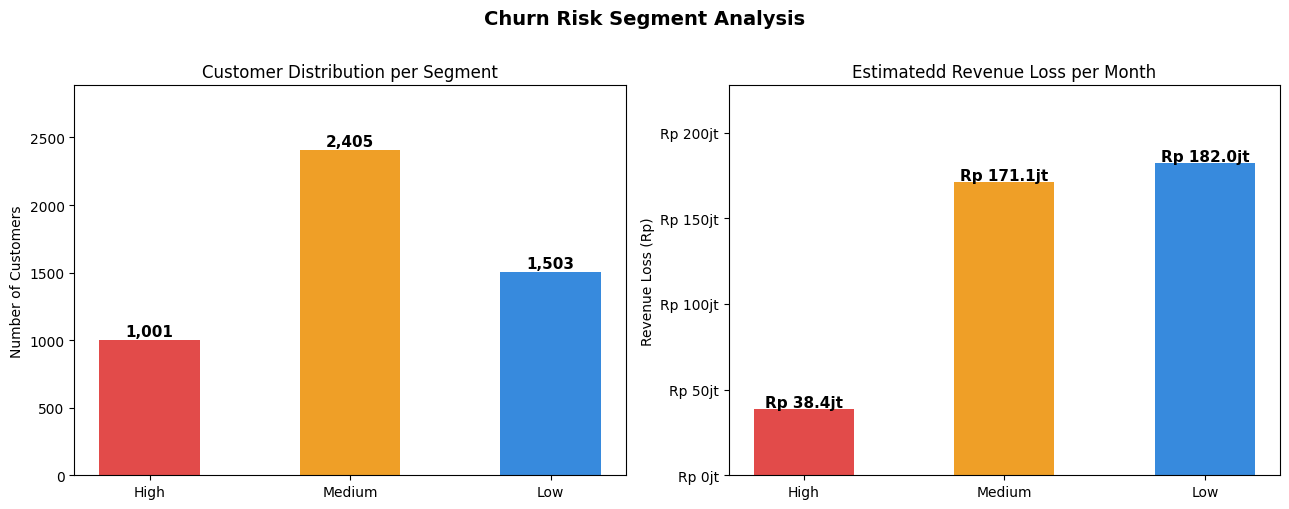

In [829]:
import matplotlib.ticker as mticker
import numpy as np

segmen      = ['High', 'Medium', 'Low']
n_customer  = [1001, 2405, 1503]
rev_loss    = [38_399_390, 171_102_888, 182_047_013]
colors      = ['#E24B4A', '#EF9F27', '#378ADD']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Churn Risk Segment Analysis', fontsize=14, fontweight='bold', y=1.01)

# --- chart 1: jumlah customer ---
bars1 = axes[0].bar(segmen, n_customer, color=colors, width=0.5)
axes[0].set_title('Customer Distribution per Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, max(n_customer) * 1.2)
for bar, val in zip(bars1, n_customer):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# --- chart 2: estimasi revenue loss ---
bars2 = axes[1].bar(segmen, rev_loss, color=colors, width=0.5)
axes[1].set_title('Estimatedd Revenue Loss per Month')
axes[1].set_ylabel('Revenue Loss (Rp)')
axes[1].set_ylim(0, max(rev_loss) * 1.25)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}jt')
)
for bar, val in zip(bars2, rev_loss):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1_500_000,
                 f'Rp {val/1e6:.1f}jt', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('segment_analysis.png', bbox_inches='tight')
plt.show()

**Insight:** The visualisation above reinforces two key findings:
- The **Medium** segment is the largest group (2,405 customers) and
  holds the highest revenue at risk (IDR 171.1M/month) — making it
  the top retention priority
- The **High** segment, despite having the highest churn probability,
  has the smallest revenue at risk because customers in this group
  typically have low transaction frequency